<a href="https://colab.research.google.com/github/ekttd/VAST-Challenge/blob/main/sunday_crime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Анализ воскресенья на преступление.**
### **Гипотеза**: предполагаемое время преступления - 11:45-12:00  


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

In [ ]:
fri_url = "https://github.com/ekttd/VAST-Challenge/raw/main/MC2%202015%20Data/comm-data-Fri.csv"
sat_url = "https://github.com/ekttd/VAST-Challenge/raw/main/MC2%202015%20Data/comm-data-Sat.csv"
sun_url = "https://github.com/ekttd/VAST-Challenge/raw/main/MC2%202015%20Data/comm-data-Sun.csv"
df_fri = pd.read_csv(fri_url)
df_sat = pd.read_csv(sat_url)
df_sun = pd.read_csv(sun_url)
df_sun.head()

,Timestamp,from,to,location
0,2014-6-08 08:01:05,1401601,839736,Kiddie Land
1,2014-6-08 08:01:16,1169163,600636,Entry Corridor
2,2014-6-08 08:01:16,1169163,1561994,Entry Corridor
3,2014-6-08 08:01:16,1169163,864634,Entry Corridor
4,2014-6-08 08:01:16,1169163,577530,Entry Corridor


In [ ]:
print(f"\nУникальные значения в location:")
print(df_sun['location'].unique())


Уникальные значения в location:
['Kiddie Land' 'Entry Corridor' 'Tundra Land' 'Wet Land' 'Coaster Alley']


# **Анимированная тепловая карта по локациям по 15-минутным интервалам в воскресенье**

In [ ]:
!pip install plotly nbformat pillow

import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import requests
from PIL import Image
from io import BytesIO
import base64

In [ ]:
# Timestamp для временной динамики
df_anim = pd.read_csv(sun_url)
df_anim['Timestamp'] = pd.to_datetime(df_anim['Timestamp'])

In [ ]:
#координаты для локаций фиксированные
location_coords = {
    'Tundra Land': (1000, 900),
    'Entry Corridor': (2500, 900),
    'Kiddie Land': (3500, 700),
    'Wet Land': (1600, 2200),
    'Coaster Alley': (2000, 2800)
}

locations_df = pd.DataFrame([
    {'location': loc, 'x': coords[0], 'y': coords[1]}
    for loc, coords in location_coords.items()
])

map_url = "https://github.com/ekttd/VAST-Challenge/raw/main/MC2%202015%20Data/map.jpg"
response = requests.get(map_url)
img = Image.open(BytesIO(response.content))

img.save('map_temp.jpg')

with open('map_temp.jpg', 'rb') as f:
    encoded_image = base64.b64encode(f.read()).decode('ascii')


In [ ]:
df_anim['time_rounded'] = df_anim['Timestamp'].dt.floor('15min')
df_anim['time_str'] = df_anim['time_rounded'].dt.strftime('%H:%M')

time_points = sorted(df_anim['time_str'].unique())

In [ ]:
#шкала сообщений
global_max_counts = []
for time_point in time_points:
    df_time = df_anim[df_anim['time_str'] == time_point]
    counts = df_time['location'].value_counts()
    if not counts.empty:
        global_max_counts.append(counts.max())

global_max = max(global_max_counts) if global_max_counts else 1
print(f"Глобальный максимум сообщений за 15-минутный интервал: {global_max}")

Глобальный максимум сообщений за 15-минутный интервал: 28720


In [ ]:
# функция для подсчета количества сообщений по локациям для конкретного времени
def get_location_counts(df_time):
    counts = df_time['location'].value_counts().reset_index()
    counts.columns = ['location', 'count']

    result = locations_df.merge(counts, on='location', how='left')

    result['count'] = result['count'].fillna(0)

    result['size_norm'] = result['count'] / global_max * 50 + 20
    result['color_norm'] = result['count'] / global_max

    result['size_norm'] = result['size_norm'].clip(20, 70)
    result['color_norm'] = result['color_norm'].clip(0, 1)

    return result

In [ ]:
frames = []

for time_point in time_points:
    df_time = df_anim[df_anim['time_str'] == time_point]

    #агрегированные данные по локациям
    location_counts = get_location_counts(df_time)


    frame = go.Frame(
        data=[go.Scatter(
            x=location_counts['x'],
            y=location_counts['y'],
            mode='markers+text',
            marker=dict(
                size=location_counts['size_norm'],
                color=location_counts['color_norm'],
                colorscale='YlOrRd',
                showscale=True,
                colorbar=dict(
                    title="Количество сообщений<br>(относительно макс.)",
                    titleside="right",
                    x=1.02,
                    tickmode='array',
                    tickvals=[0, 0.25, 0.5, 0.75, 1],
                    ticktext=['0', f'{int(global_max*0.25)}', f'{int(global_max*0.5)}',
                             f'{int(global_max*0.75)}', f'{global_max}']
                ),
                line=dict(width=1, color='black'),
                sizemode='diameter',
                sizeref=1,
                cmin=0,
                cmax=1
            ),
            text=location_counts.apply(
                lambda row: f"<b>{row['location']}</b><br>Сообщений: {int(row['count'])}",
                axis=1
            ),
            textposition="top center",
            textfont=dict(size=10, color='black', family='Arial Black'),
            hoverinfo='text',
            name=''
        )],
        name=time_point
    )
    frames.append(frame)

fig = go.Figure()

In [ ]:
fig.add_layout_image(
    dict(
        source=f'data:image/jpg;base64,{encoded_image}',
        xref="x",
        yref="y",
        x=0,
        y=3200,
        sizex=4200,
        sizey=3200,
        sizing="stretch",
        opacity=0.5,
        layer="below"
    )
)

# начальные данные
first_time = time_points[0]
first_data = df_anim[df_anim['time_str'] == first_time]
first_counts = get_location_counts(first_data)

# трейсы
fig.add_trace(go.Scatter(
    x=first_counts['x'],
    y=first_counts['y'],
    mode='markers+text',
    marker=dict(
        size=first_counts['size_norm'],
        color=first_counts['color_norm'],
        colorscale='YlOrRd',
        showscale=True,
        colorbar=dict(
            title="Количество сообщений<br>(относительно макс.)",
            titleside="right",
            x=1.02,
            tickmode='array',
            tickvals=[0, 0.25, 0.5, 0.75, 1],
            ticktext=['0', f'{int(global_max*0.25)}', f'{int(global_max*0.5)}',
                     f'{int(global_max*0.75)}', f'{global_max}']
        ),
        line=dict(width=1, color='black'),
        sizemode='diameter',
        sizeref=1,
        cmin=0,
        cmax=1
    ),
    text=first_counts.apply(
        lambda row: f"<b>{row['location']}</b><br>Сообщений: {int(row['count'])}",
        axis=1
    ),
    textposition="top center",
    textfont=dict(size=10, color='black', family='Arial Black'),
    hoverinfo='text',
    name=''
))

fig.frames = frames

In [ ]:
# слайдер
sliders = [dict(
    active=0,
    steps=[dict(
        method='animate',
        args=[[f.name], dict(mode='immediate', frame=dict(duration=500, redraw=True))],
        label=f.name
    ) for f in frames],
    transition=dict(duration=300),
    x=0.1,
    y=0,
    currentvalue=dict(
        font=dict(size=12),
        prefix='Время (15-мин интервал): ',
        visible=True,
        xanchor='right'
    ),
    len=0.9
)]

# кнопки управления
play_button = dict(
    label="Play",
    method="animate",
    args=[None, dict(frame=dict(duration=500, redraw=True), fromcurrent=True)]
)

pause_button = dict(
    label="Pause",
    method="animate",
    args=[[None], dict(frame=dict(duration=0, redraw=False), mode='immediate')]
)

# макет
fig.update_layout(
    width=1200,
    height=900,
    title={
        'text': f'Тепловая карта сообщений (15-минутные интервалы, макс: {global_max} сообщ.)',
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=16)
    },
    xaxis=dict(
        range=[0, 4200],
        showgrid=False,
        visible=False
    ),
    yaxis=dict(
        range=[0, 3200],
        showgrid=False,
        visible=False,
        scaleanchor="x",
        scaleratio=1
    ),
    showlegend=False,
    updatemenus=[dict(
        type='buttons',
        buttons=[play_button, pause_button],
        direction='left',
        pad=dict(r=10, t=10),
        showactive=False,
        x=0.1,
        y=0.1,
        xanchor='right',
        yanchor='top'
    )],
    sliders=sliders,
    margin=dict(l=50, r=50, t=100, b=50)
)

fig.show()

### В 11:45-12:00 происходит сильный всплеск активности в Wet Land. Рассмотрим его подробнее и отфильтруем сообщения только из Wet Land, там предположительно произошло преступление.

In [ ]:
wet_land_df = df_sun[df_sun['location'] == 'Wet Land'].copy()

print(f"\nВсего сообщений в воскресенье: {len(df_sun)}")
print(f"Сообщений из Wet Land: {len(wet_land_df)}")


Всего сообщений в воскресенье: 1548724
Сообщений из Wet Land: 598728


In [ ]:
wet_land_df['datetime'] = pd.to_datetime(wet_land_df['Timestamp'])
wet_land_df['time_rounded'] = wet_land_df['datetime'].dt.floor('1min')

In [ ]:
external_msgs = wet_land_df[wet_land_df['to'] == 'external'].copy()
service_msgs = wet_land_df[wet_land_df['to'] == "839736"].copy()
print(f"Сообщений в external из Wet Land: {len(external_msgs)}")
print(f"Сообщений в 839736 из Wet Land: {len(service_msgs)}")

Сообщений в external из Wet Land: 14794
Сообщений в 839736 из Wet Land: 33048


In [ ]:
external_by_min = external_msgs.groupby('time_rounded').size().reset_index(name='count')
service_by_min = service_msgs.groupby('time_rounded').size().reset_index(name='count')
start_time = pd.Timestamp('2014-6-08 08:00:00')
end_time = pd.Timestamp('2014-6-08 23:00:00')
all_times = pd.date_range(start_time, end_time, freq='1min')


external_full = pd.DataFrame({'time_rounded': all_times})
external_full = external_full.merge(external_by_min, on='time_rounded', how='left').fillna(0)

service_full = pd.DataFrame({'time_rounded': all_times})
service_full = service_full.merge(service_by_min, on='time_rounded', how='left').fillna(0)

In [ ]:
def get_time_labels(times, step_minutes=30):
    labels = []
    for i, t in enumerate(times):
        if i % step_minutes == 0:
            labels.append(t.strftime('%H:%M'))
        else:
            labels.append('')
    return labels

/tmp/ipykernel_462/2682579830.py:45: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/tmp/ipykernel_462/2682579830.py:46: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/tmp/ipykernel_462/2682579830.py:45: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/tmp/ipykernel_462/2682579830.py:46: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



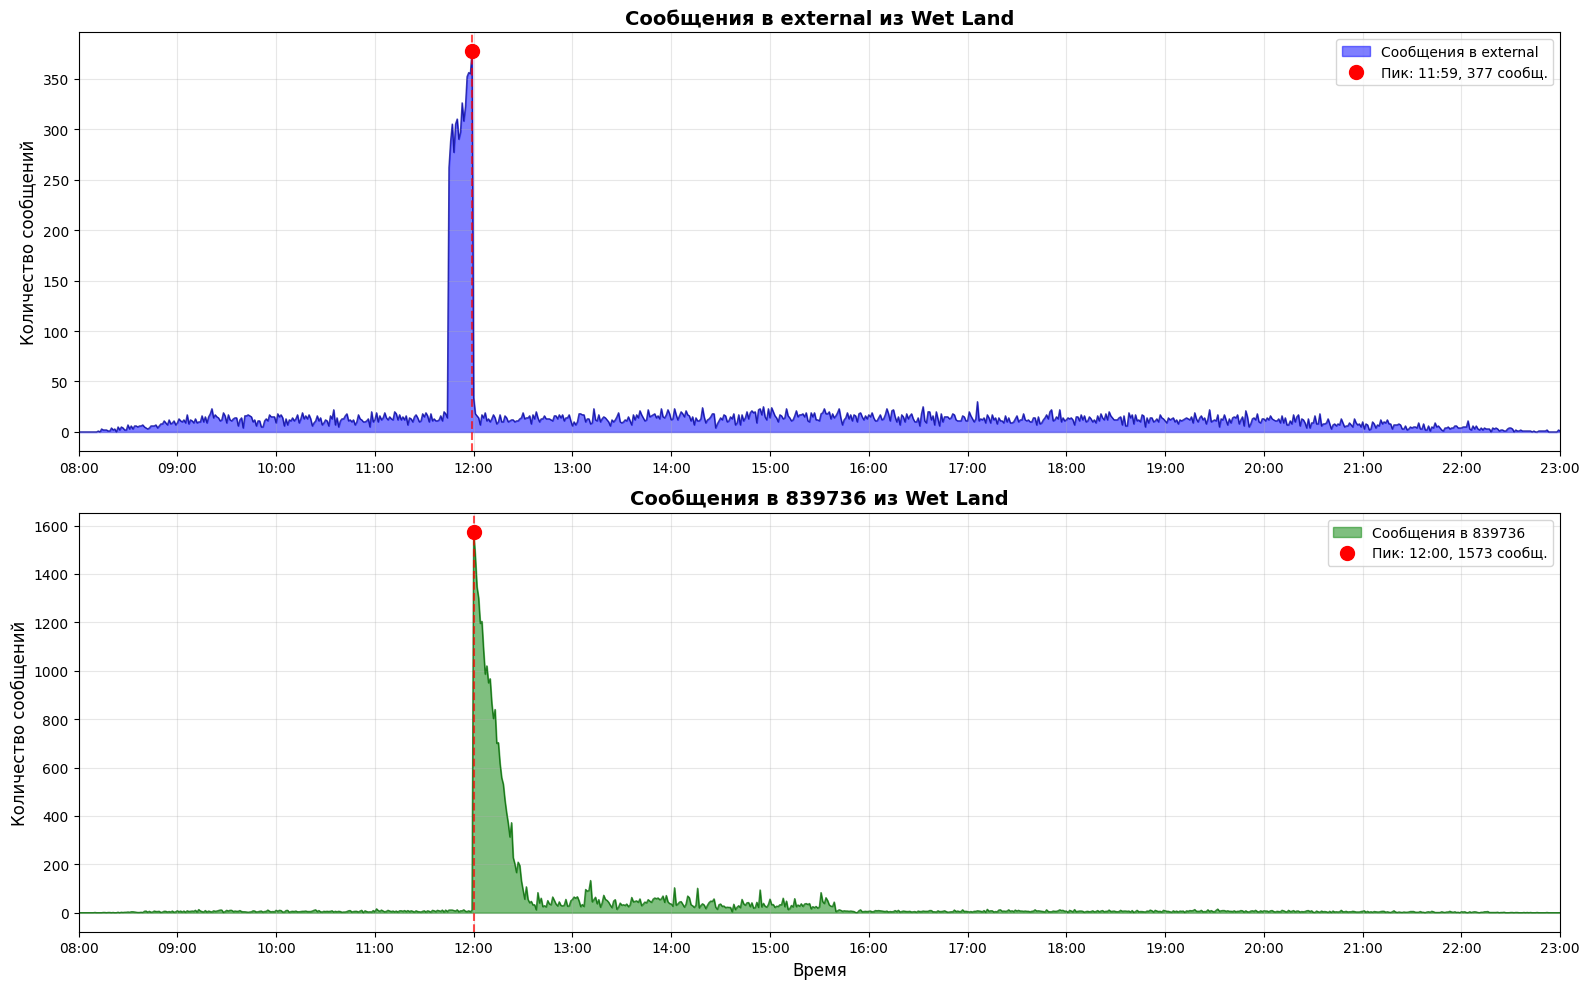

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# cообщения в external
ax1.fill_between(external_full['time_rounded'], external_full['count'],
                 alpha=0.5, color='blue', label='Сообщения в external')
ax1.plot(external_full['time_rounded'], external_full['count'],
         color='darkblue', linewidth=1, alpha=0.7)
ax1.set_title('Сообщения в external из Wet Land', fontsize=14, fontweight='bold')
ax1.set_ylabel('Количество сообщений', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()

# пик external
ext_peak_idx = external_full['count'].idxmax()
ext_peak_time = external_full.loc[ext_peak_idx, 'time_rounded']
ext_peak_val = external_full.loc[ext_peak_idx, 'count']
ax1.plot(ext_peak_time, ext_peak_val, 'ro', markersize=10,
         label=f'Пик: {ext_peak_time.strftime("%H:%M")}, {ext_peak_val:.0f} сообщ.')
ax1.axvline(x=ext_peak_time, color='red', linestyle='--', alpha=0.7)
ax1.legend(loc='upper right')

# cообщения в 839736
ax2.fill_between(service_full['time_rounded'], service_full['count'],
                 alpha=0.5, color='green', label='Сообщения в 839736')
ax2.plot(service_full['time_rounded'], service_full['count'],
         color='darkgreen', linewidth=1, alpha=0.7)
ax2.set_title('Сообщения в 839736 из Wet Land',
              fontsize=14, fontweight='bold')
ax2.set_ylabel('Количество сообщений', fontsize=12)
ax2.set_xlabel('Время', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend()

# пик 839736
serv_peak_idx = service_full['count'].idxmax()
serv_peak_time = service_full.loc[serv_peak_idx, 'time_rounded']
serv_peak_val = service_full.loc[serv_peak_idx, 'count']
ax2.plot(serv_peak_time, serv_peak_val, 'ro', markersize=10,
         label=f'Пик: {serv_peak_time.strftime("%H:%M")}, {serv_peak_val:.0f} сообщ.')
ax2.axvline(x=serv_peak_time, color='red', linestyle='--', alpha=0.7)
ax2.legend(loc='upper right')

for ax in [ax1, ax2]:
    ax.set_xlim(start_time, end_time)
    ax.set_xticks(pd.date_range(start_time, end_time, freq='1H'))
    ax.set_xticklabels([t.strftime('%H:%M') for t in pd.date_range(start_time, end_time, freq='1H')])

plt.tight_layout()
plt.show()

### Это **подтверждает** ранее выдвинутую **гипотезу** о том, что люди в парке сразу после преступления (примерно в 11:40) начали писать в external, рассказать друзьям/в соц сетях о том, что произошло. И только после этого люди обращаются в службу поддержки парка (839736).   


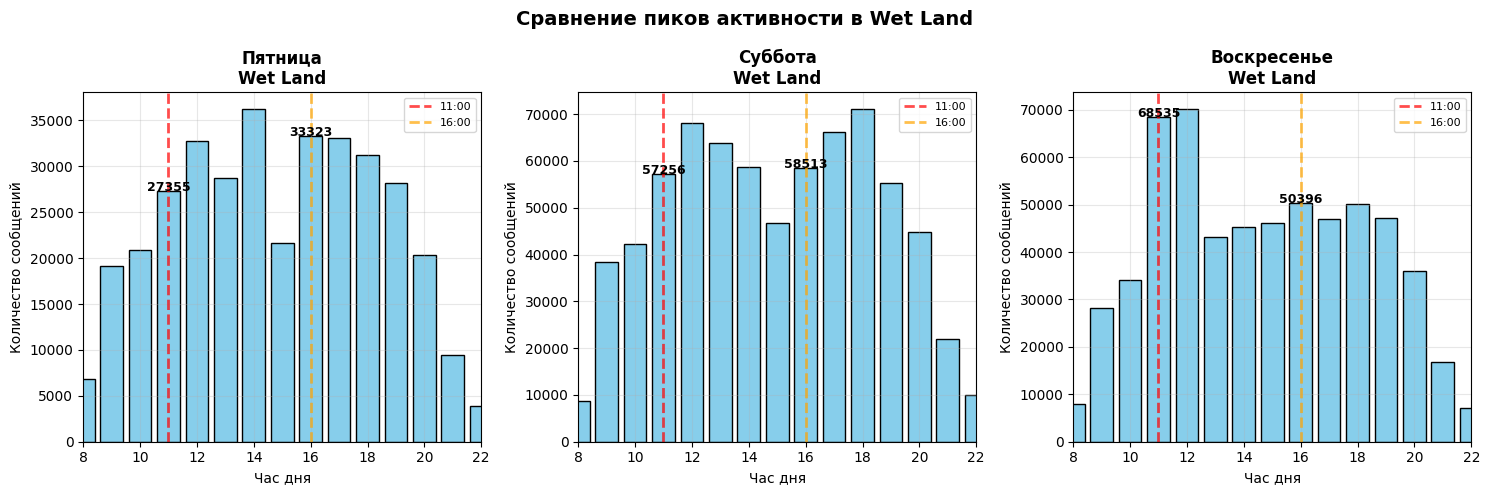

In [ ]:
# Загружаем данные для всех дней
df_fri = pd.read_csv(fri_url)
df_sat = pd.read_csv(sat_url)
df_sun = pd.read_csv(sun_url)

# Добавляем колонку с часом
for df in [df_fri, df_sat, df_sun]:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['hour'] = df['Timestamp'].dt.hour

days = ['Пятница', 'Суббота', 'Воскресенье']
dfs = [df_fri, df_sat, df_sun]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (day_name, df_day) in enumerate(zip(days, dfs)):
    # Фильтруем только Wet Land
    coaster = df_day[df_day['location'] == 'Wet Land']
    # Группируем по часам
    hourly = coaster.groupby('hour').size().reindex(range(24), fill_value=0)

    ax = axes[idx]
    ax.bar(hourly.index, hourly.values, color='skyblue', edgecolor='black')
    ax.axvline(x=11, color='red', linestyle='--', alpha=0.7, linewidth=2, label='11:00')
    ax.axvline(x=16, color='orange', linestyle='--', alpha=0.7, linewidth=2, label='16:00')
    ax.set_title(f'{day_name}\nWet Land', fontsize=12, fontweight='bold')
    ax.set_xlabel('Час дня', fontsize=10)
    ax.set_ylabel('Количество сообщений', fontsize=10)
    ax.set_xlim(8, 22)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

    # Добавляем значения на пиках
    ax.text(11, hourly[11] + 5, f'{hourly[11]}', ha='center', fontsize=9, fontweight='bold')
    ax.text(16, hourly[16] + 5, f'{hourly[16]}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Сравнение пиков активности в Wet Land',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## В пятницу и субботу есть два пика активности - в +-12 и в +-18. В воскресенье второй пик пропадает, тк (по нашей теории) в первой половине дня было совершено преступление, соответственно во второй половине дня активности могли быть отменены или люди покинули территорию парка.